In [69]:
# Assistant
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Two options to fix this issue:

# Option 1: Downgrade NumPy to a version before 2.0
# !pip install numpy<2.0

# Option 2: If you need to use np.unicode_ in your code, replace it with np.str_
# For example, if you have code like:
# my_unicode = np.unicode_(some_string)
# Change it to:
# my_unicode = np.str_(some_string)

In [70]:
df = pd.read_csv('Z:\Machine_Learning\smart_traffic\smart_traffic/challenging_traffic_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (3000, 12)


,timestamp,location_id,traffic_volume,avg_vehicle_speed,vehicle_count_cars,vehicle_count_trucks,vehicle_count_bikes,weather_condition,temperature,humidity,accident_reported,signal_status
0,2024-01-01 00:00:00,8,900,20.88,471,0,42,Rainy,16.80,73.70,0,Red
1,2024-01-01 00:10:00,2,958,5.00,549,0,0,Cloudy,22.32,69.30,0,Red
2,2024-01-01 00:20:00,2,797,10.60,407,0,26,Rainy,14.06,42.53,0,Green
3,2024-01-01 00:30:00,1,801,14.22,188,158,0,Rainy,14.21,61.94,0,Yellow
4,2024-01-01 00:40:00,5,989,13.89,333,60,0,Cloudy,16.41,36.43,0,Red


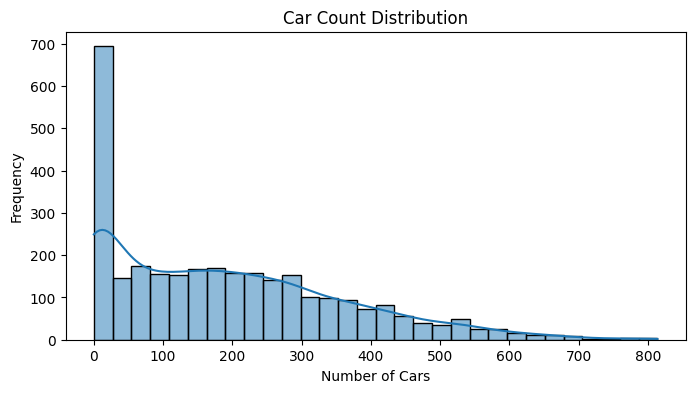

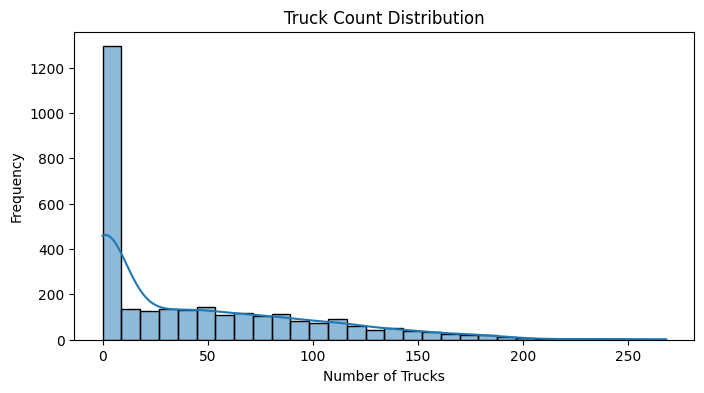

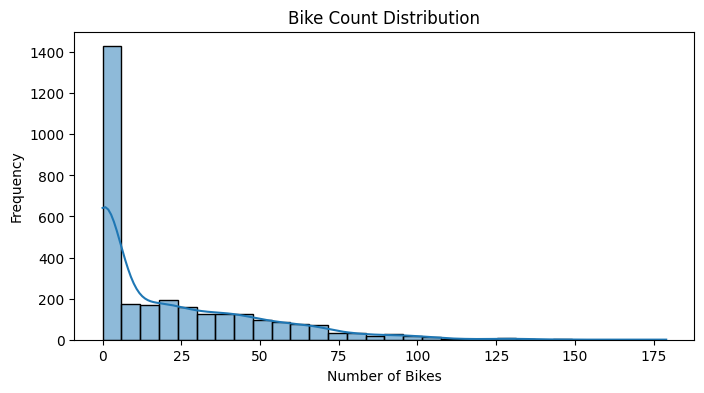

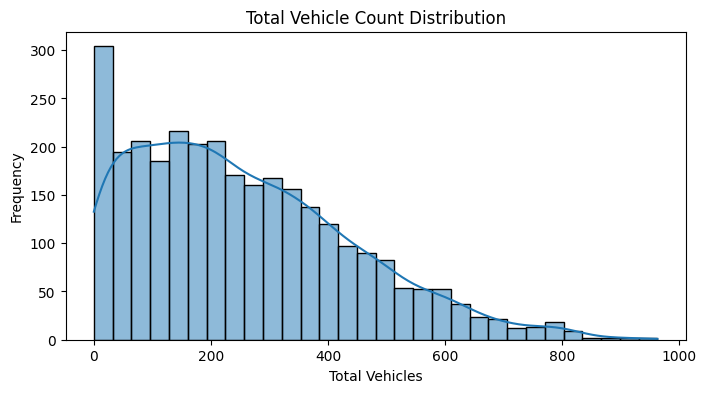

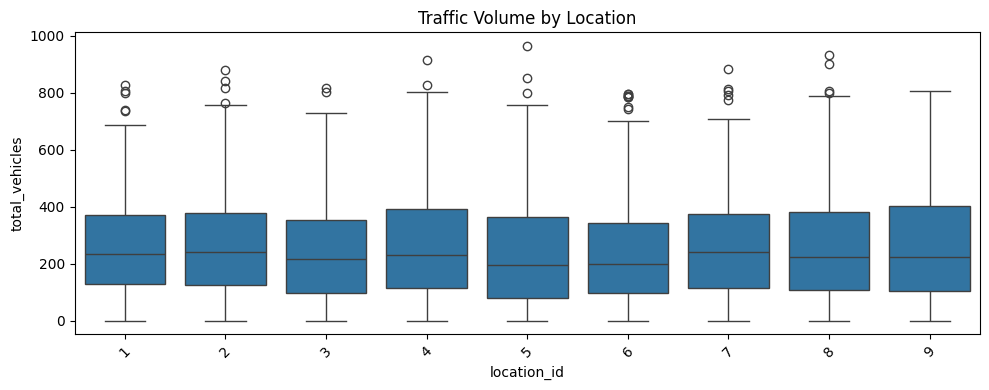

In [71]:
# Vehicle count distribution (cars, trucks, bikes)
plt.figure(figsize=(8, 4))
sns.histplot(df['vehicle_count_cars'], bins=30, kde=True)
plt.title("Car Count Distribution")
plt.xlabel("Number of Cars")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['vehicle_count_trucks'], bins=30, kde=True)
plt.title("Truck Count Distribution")
plt.xlabel("Number of Trucks")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['vehicle_count_bikes'], bins=30, kde=True)
plt.title("Bike Count Distribution")
plt.xlabel("Number of Bikes")
plt.ylabel("Frequency")
plt.show()

# Total vehicle count distribution
df['total_vehicles'] = df['vehicle_count_cars'] + df['vehicle_count_trucks'] + df['vehicle_count_bikes']
plt.figure(figsize=(8, 4))
sns.histplot(df['total_vehicles'], bins=30, kde=True)
plt.title("Total Vehicle Count Distribution")
plt.xlabel("Total Vehicles")
plt.ylabel("Frequency")
plt.show()

# Traffic by Location
plt.figure(figsize=(10, 4))
sns.boxplot(x='location_id', y='total_vehicles', data=df)
plt.title("Traffic Volume by Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [72]:
# Feature Engineering
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['Hour'] = df['timestamp'].dt.hour
df['Day'] = df['timestamp'].dt.day
df['Month'] = df['timestamp'].dt.month
df['DayOfWeek'] = df['timestamp'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['IsPeak'] = df['Hour'].apply(lambda x: 1 if 7 <= x <= 9 or 17 <= x <= 19 else 0)

# Label encoding for location_id and other categorical columns
le = LabelEncoder()
df['location_id'] = le.fit_transform(df['location_id'])
df['weather_condition'] = le.fit_transform(df['weather_condition'])
df['accident_reported'] = le.fit_transform(df['accident_reported'].astype(str))
df['signal_status'] = le.fit_transform(df['signal_status'].astype(str))

df.drop(columns=['timestamp'], inplace=True)
df.fillna(method='ffill', inplace=True)


In [73]:
# Label encoding for weather_condition
le_weather = LabelEncoder()
df['weather_condition'] = le_weather.fit_transform(df['weather_condition'])

# If you have other categorical columns, apply LabelEncoder to them as well
df['accident_reported'] = le_weather.fit_transform(df['accident_reported'].astype(str))
df['signal_status'] = le_weather.fit_transform(df['signal_status'].astype(str))


In [74]:
print(df.columns)


Index(['location_id', 'traffic_volume', 'avg_vehicle_speed',
       'vehicle_count_cars', 'vehicle_count_trucks', 'vehicle_count_bikes',
       'weather_condition', 'temperature', 'humidity', 'accident_reported',
       'signal_status', 'total_vehicles', 'Hour', 'Day', 'Month', 'DayOfWeek',
       'IsWeekend', 'IsPeak'],
      dtype='object')


In [75]:
# DROP the columns that are just parts of the total volume
# Drop the volume AND the vehicle counts to force the AI to 'think'
X = df.drop(['traffic_volume', 'vehicle_count_cars', 'vehicle_count_trucks', 'vehicle_count_bikes'], axis=1)
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [76]:
rf = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(rf, params, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
MAE: 109.91600000000001
R² Score: 0.7539412272795377


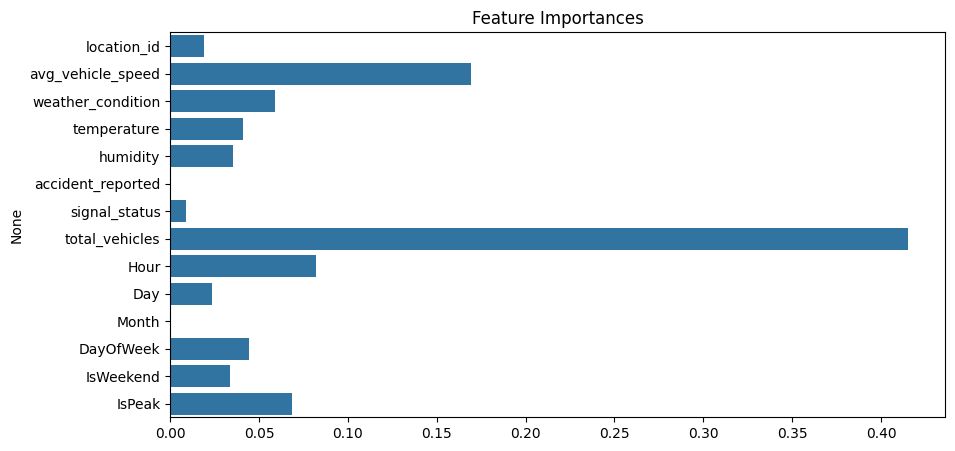

In [77]:
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances")
plt.show()


In [78]:
def signal_strategy(pred):
    if pred > 300:
        return "🔴 Critical congestion – activate alternate route and extend green by 60s"
    elif pred > 150:
        return "🟠 Heavy – extend green by 30s"
    elif pred > 70:
        return "🟡 Moderate – keep normal timings"
    else:
        return "🟢 Low – reduce green or allow pedestrian cycle"

# Apply strategy to top 10 predictions
for i in range(50):
    print(f"Vehicles: {y_pred[i]:.2f} → {signal_strategy(y_pred[i])}")


Vehicles: 341.98 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 246.37 → 🟠 Heavy – extend green by 30s
Vehicles: 360.57 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 171.29 → 🟠 Heavy – extend green by 30s
Vehicles: 273.54 → 🟠 Heavy – extend green by 30s
Vehicles: 79.26 → 🟡 Moderate – keep normal timings
Vehicles: 161.98 → 🟠 Heavy – extend green by 30s
Vehicles: 341.89 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 177.99 → 🟠 Heavy – extend green by 30s
Vehicles: 605.62 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 516.81 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 167.04 → 🟠 Heavy – extend green by 30s
Vehicles: 825.24 → 🔴 Critical congestion – activate alternate route and extend green by 60s
Vehicles: 272.28 → 🟠 Heavy – extend green by 30s
Vehicles: 166.28 → 🟠 Heavy – extend green by 30s
Vehic

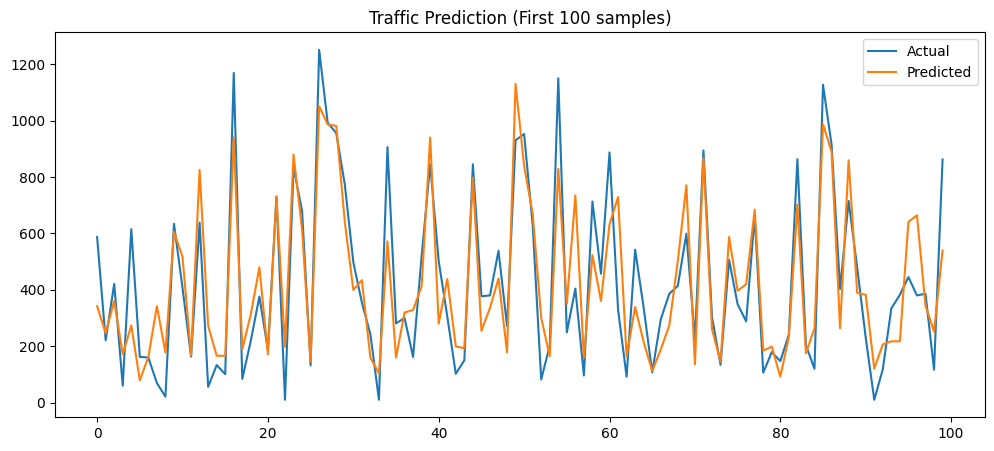

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title("Traffic Prediction (First 100 samples)")
plt.legend()
plt.show()
